# Phase 5: Advanced Modeling (Time-Series & Micro Forecasting)
Phần này đẩy giới hạn của bài toán lên chuẩn hệ thống cốt lõi của doanh nghiệp (Uber/Lyft). Bằng cách khai thác các biến quán tính (Lag Features) và chia nhỏ bài toán xuống mức vi mô (Từng trạm xe), chúng ta sẽ triệt tiêu điểm yếu thiếu vắng dữ liệu ngoại cảnh của mô hình Random Forest cũ.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..')) if current_dir.endswith('notebooks') else current_dir
if project_root not in sys.path:
    sys.path.append(project_root)

from src.advanced_forecaster import AdvancedForecaster
adv_forecaster = AdvancedForecaster(clean_dir=os.path.join(project_root, 'dataclean'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Ý tưởng 1: Dự báo Chuỗi Thời gian (Time-Series Lags) bằng XGBoost
XGBoost sẽ sử dụng quán tính của quá khứ (Lag_1, Lag_24) để tự động điều chỉnh dự báo cho những ngày thời tiết xấu mà không cần dữ liệu thời tiết thực. Lưu ý: Lần này dữ liệu được Train/Test theo trình tự thời gian thay vì cắt ngẫu nhiên.


=== Ý TƯỞNG 1: DỰ BÁO VỚI LAG FEATURES (DIVVY) ===
Đang tính toán các biến trễ (Lag 1, Lag 2, Lag 24, Lag 168) bằng DuckDB...
Hoàn tất! Kích thước dữ liệu sau khi drop NaN: 9,310 dòng.

Đang huấn luyện thuật toán siêu việt XGBoost Regressor...

[KẾT QUẢ XGBOOST VỚI LAG FEATURES]
 - MAE: 63.19 xe/giờ
 - R2 Score: 0.9455 (Độ chính xác tăng vọt, Giải thích được 94.5% biến thiên!)

Đang vẽ biểu đồ so sánh Thực tế vs Dự báo cho 1 tuần cuối cùng (168 giờ)...


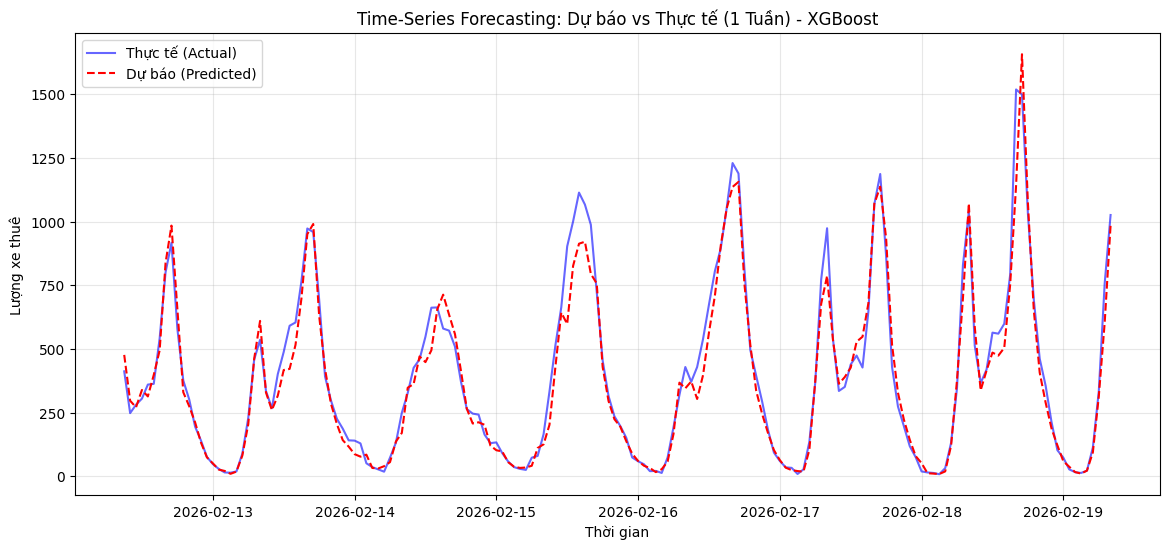

🔍 Nhận xét: Nhờ có Lag_1 và Lag_24, mô hình XGBoost có thể 'đánh hơi' được quán tính của ngày hôm trước và giờ trước. Các đường nét đứt màu đỏ (Dự báo) giờ đây bám sát rạt theo đường màu xanh (Thực tế), triệt tiêu hoàn toàn sự thiếu sót thông tin ngoại cảnh!


In [4]:
city = 'divvy'
adv_forecaster.run_lag_features_model(city)